# Data Preparation

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
# For Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
# For Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv(r"C:\Users\chand\OneDrive\Desktop\ExlR Project 01\alzheimers_disease_data.csv")
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [3]:
df.shape

(2149, 35)

In [4]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [6]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Data Cleaning

In [7]:
df.drop(columns=['DoctorInCharge','PatientID'],inplace=True)
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='object')

In [8]:
df.duplicated().sum()

0

In [9]:
df.isnull().sum()

Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfulness                0
Diagnosi

# EDA

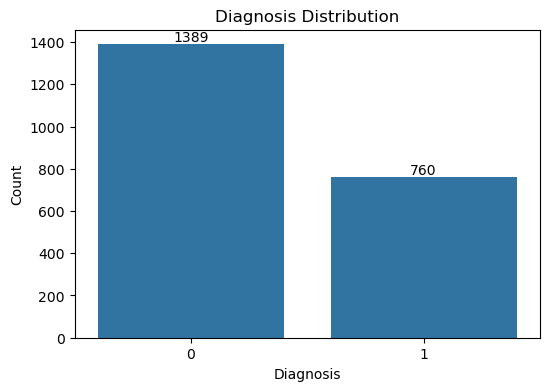

In [10]:
# Visualisation
plt.figure(figsize=(6,4))
ax = sns.countplot(x="Diagnosis", data=df)

for i in ax.containers:        # adding count labels on top of bars
    ax.bar_label(i)
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

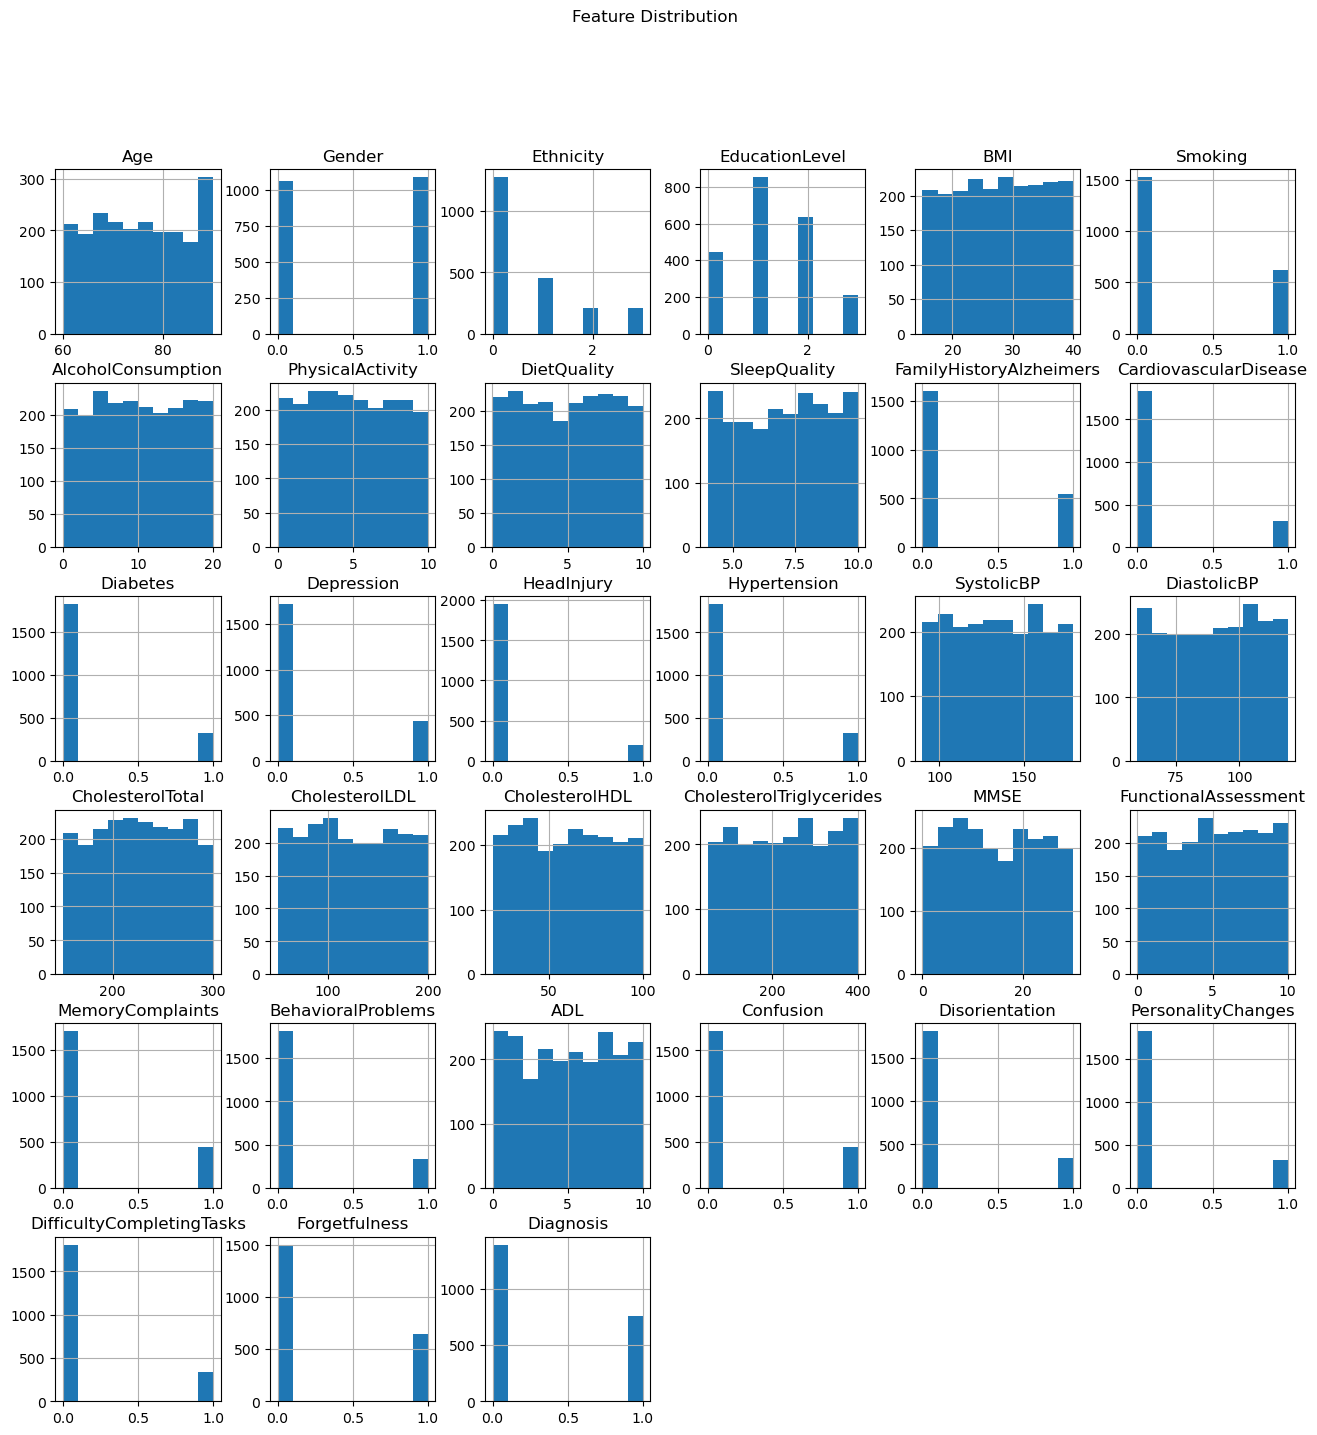

In [11]:
df.hist(figsize=(16,16),bins=10)
plt.suptitle("Feature Distribution")
plt.show()

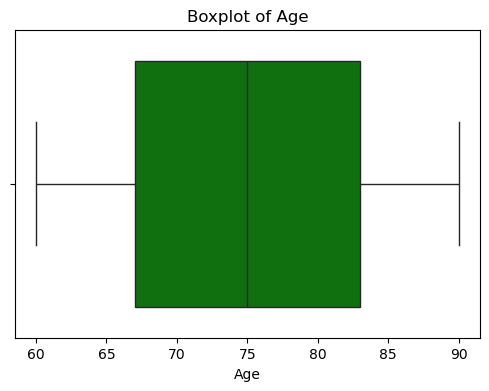

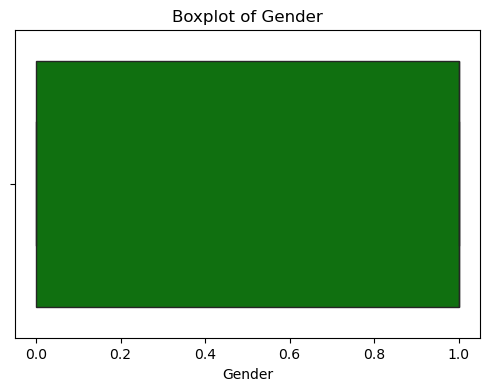

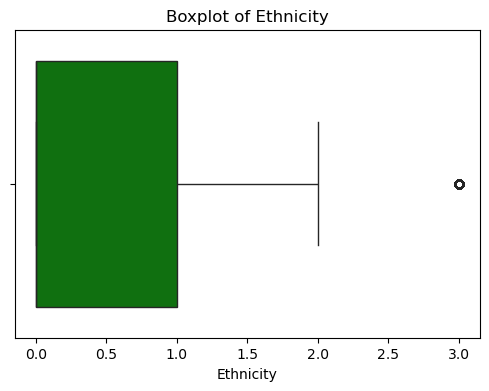

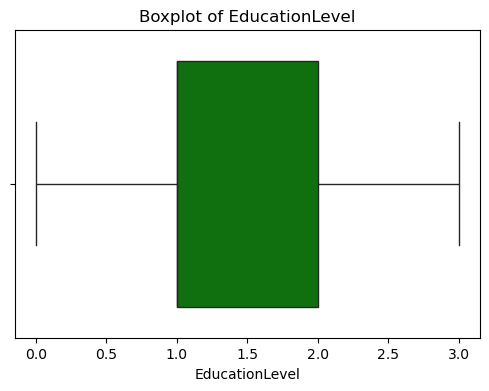

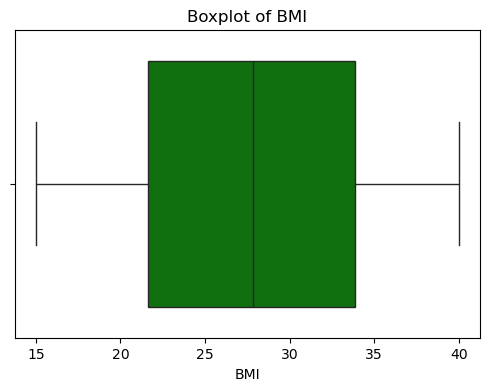

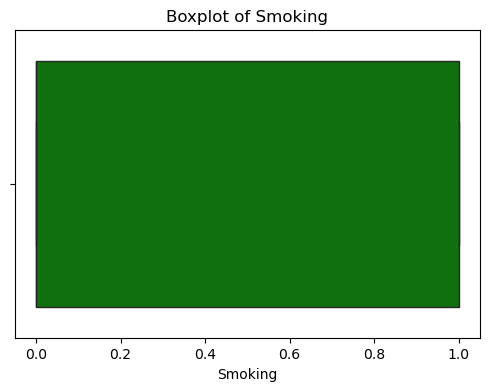

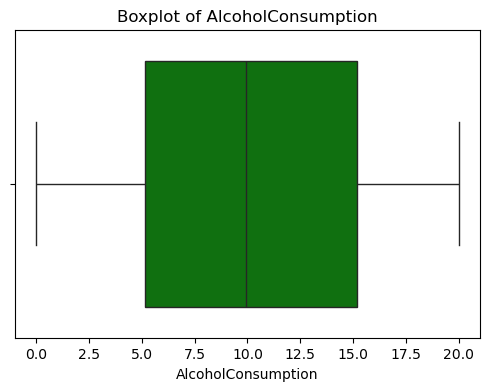

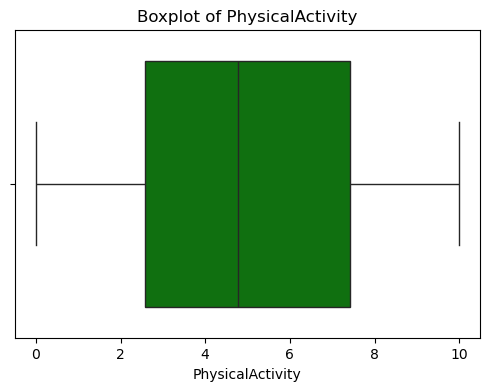

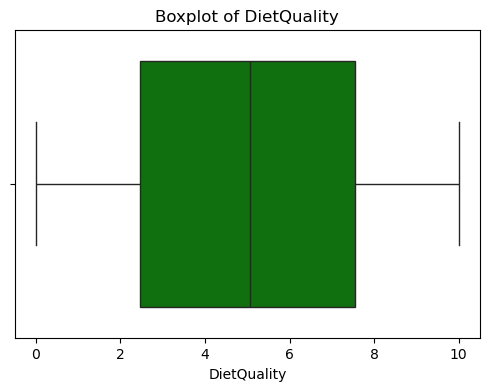

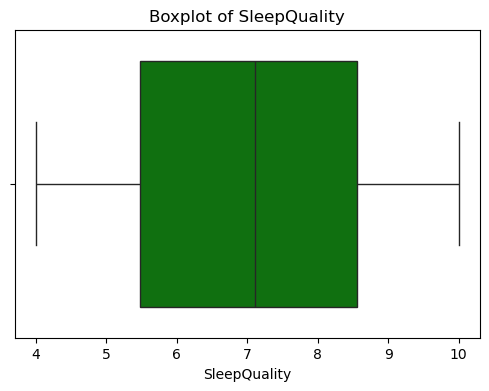

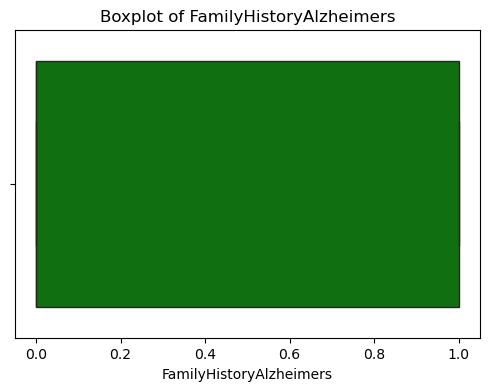

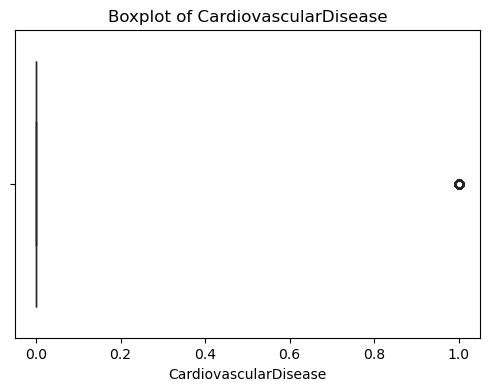

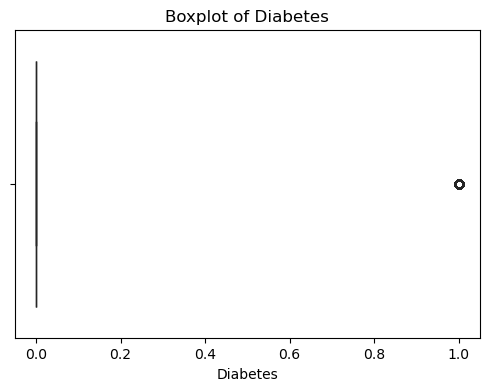

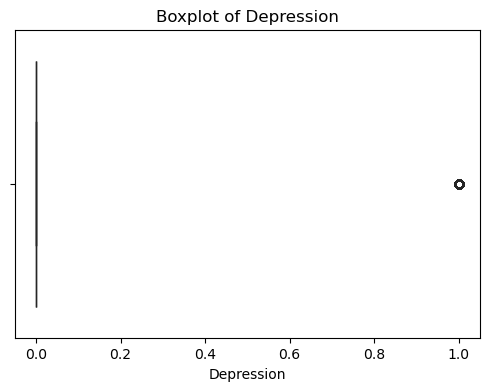

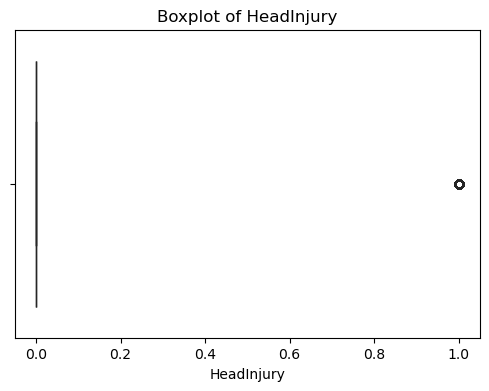

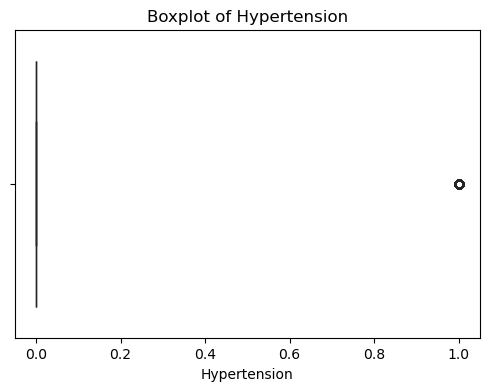

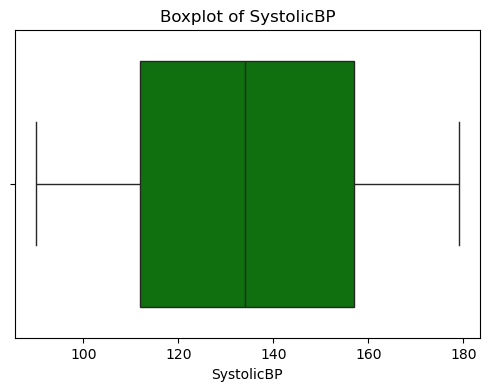

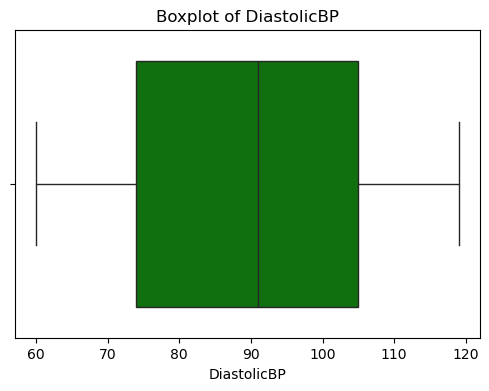

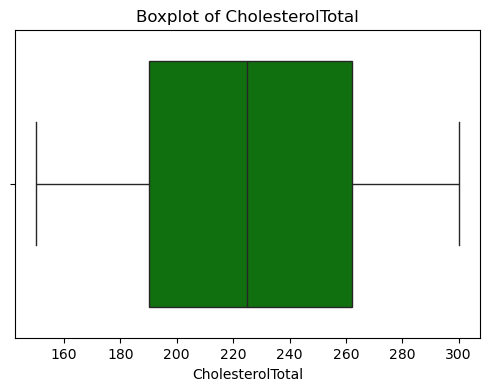

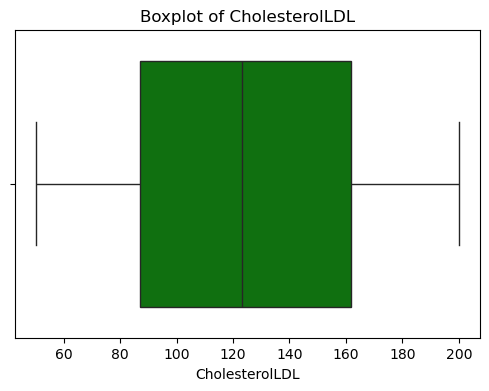

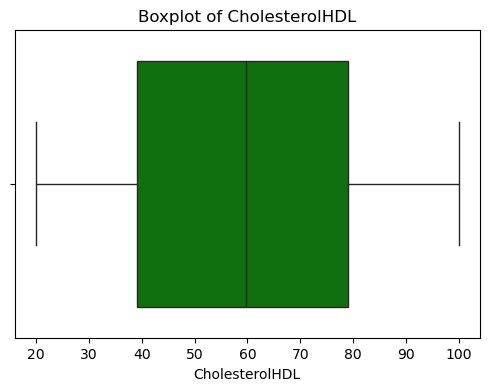

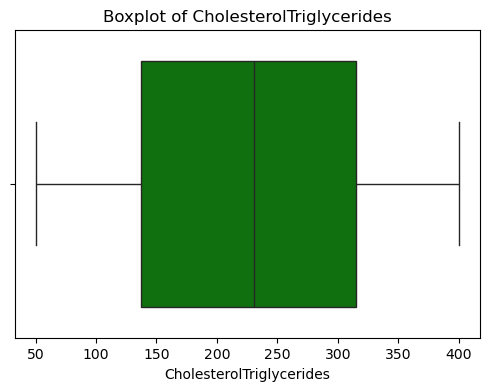

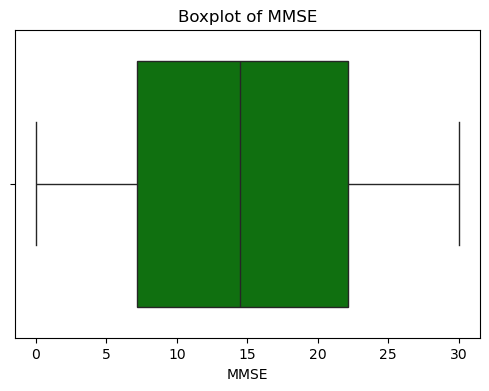

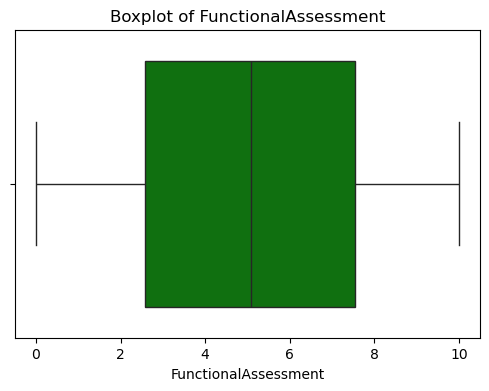

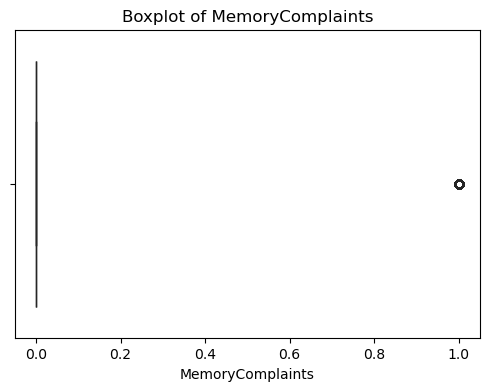

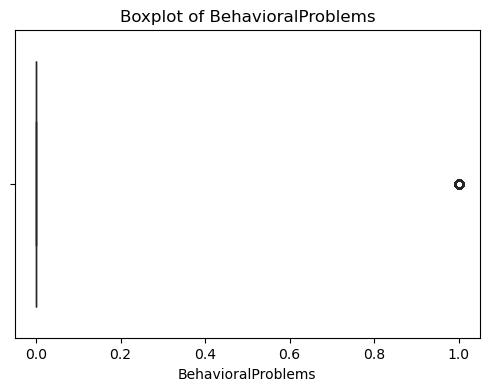

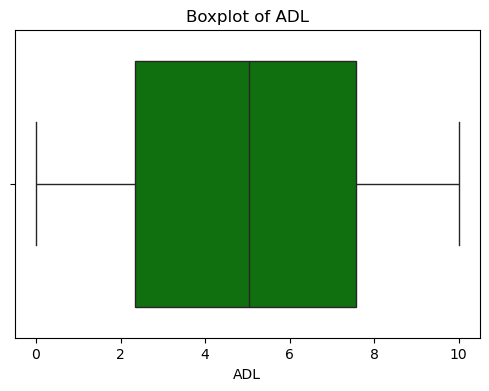

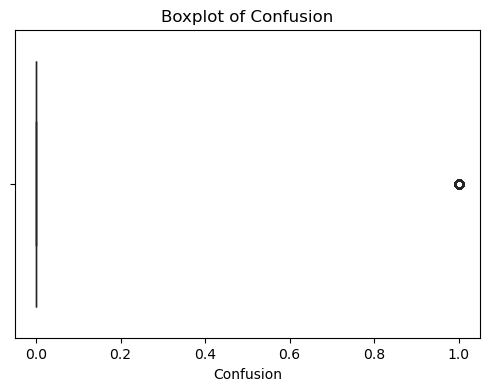

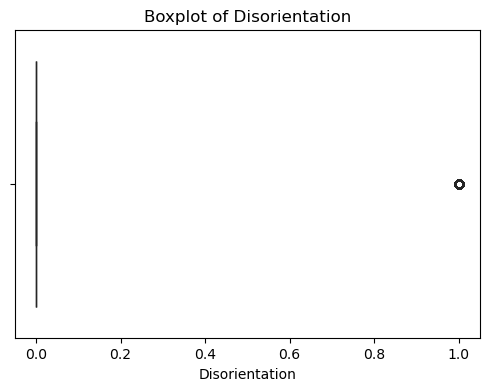

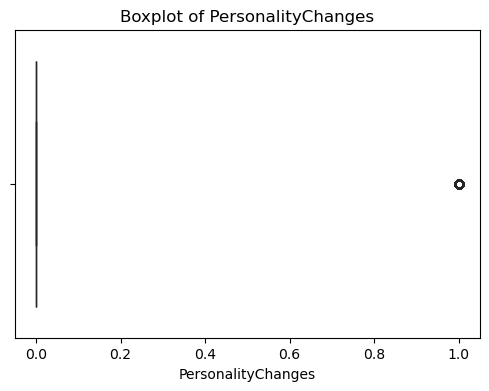

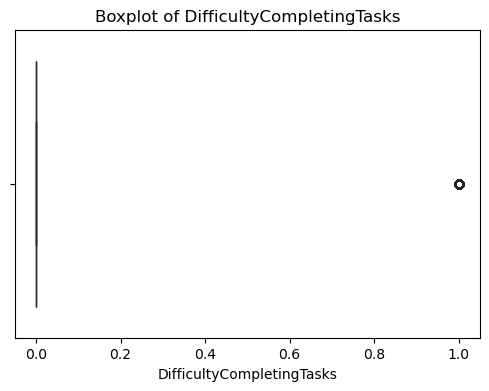

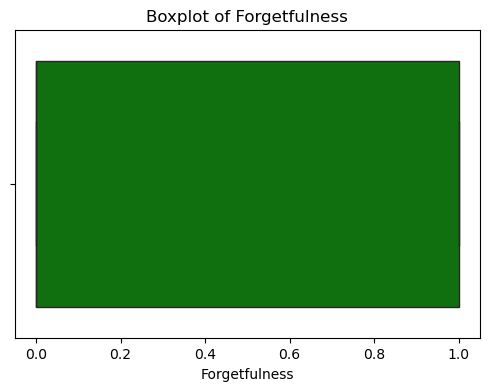

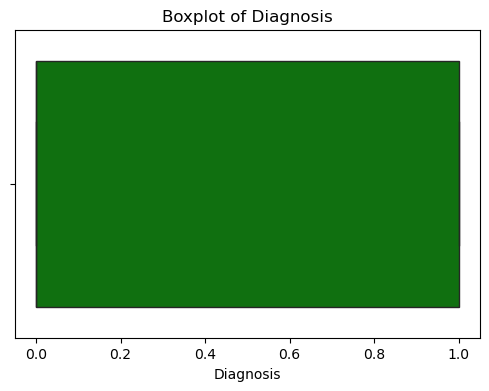

In [12]:
for i in df:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[i],color='green')
    plt.title(f"Boxplot of {i}")
    plt.show()

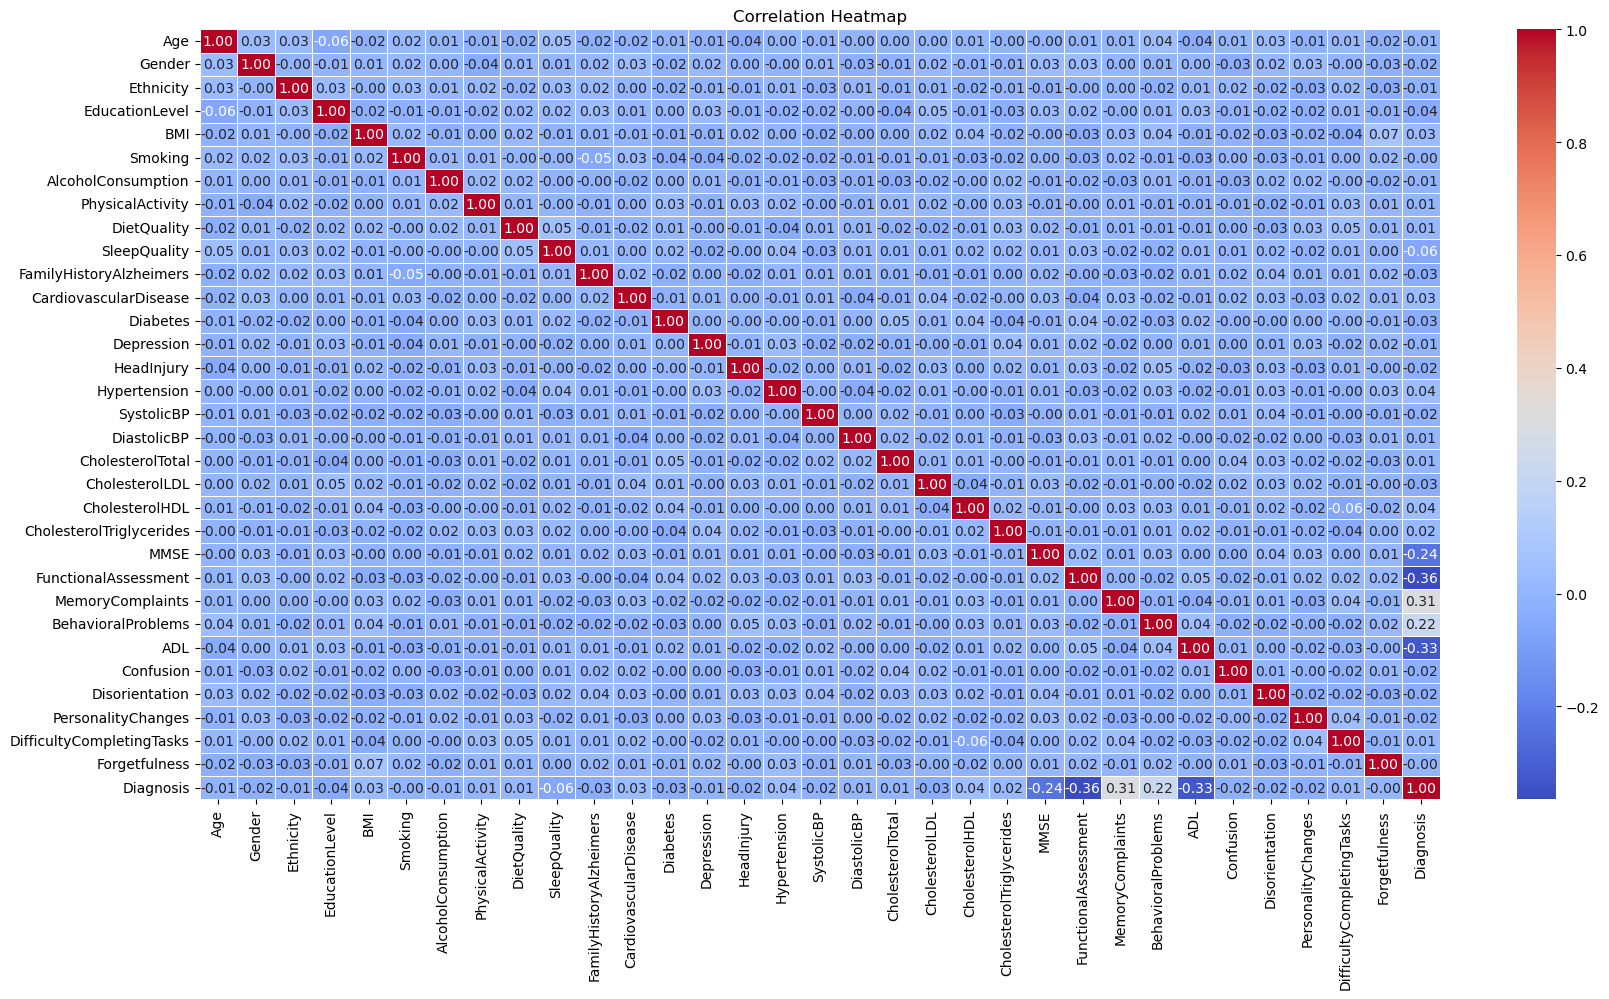

In [13]:
corr=df.corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr,annot=True,linewidth=0.5,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

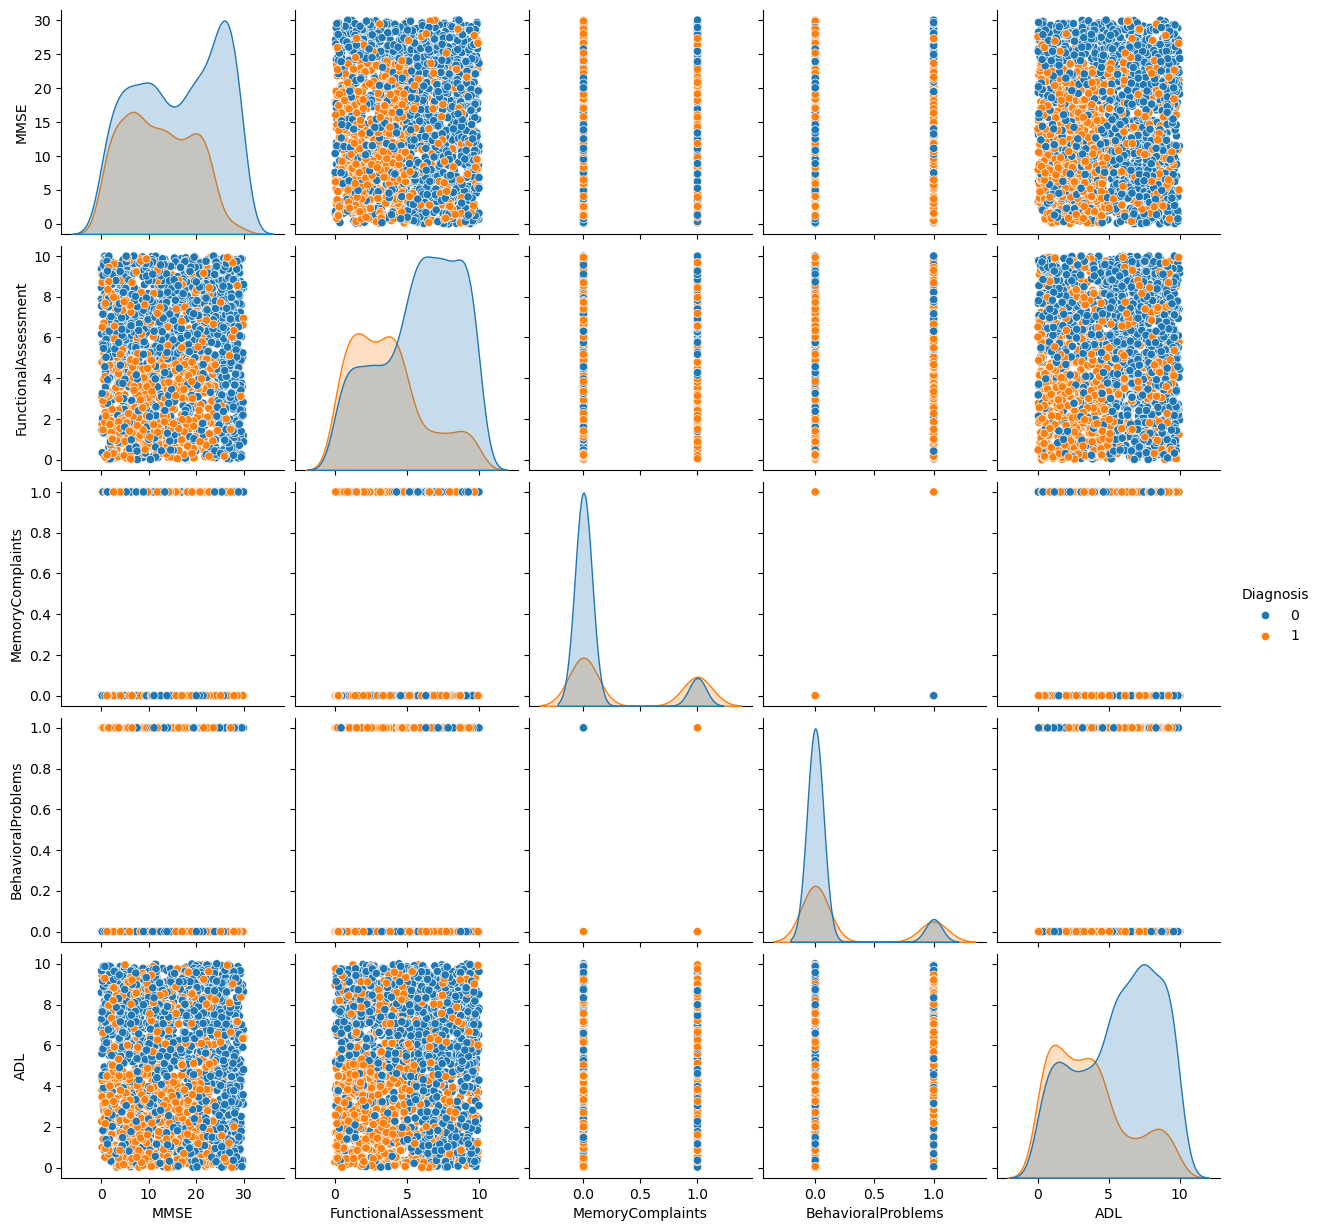

In [14]:
top_cols=['MMSE','FunctionalAssessment','MemoryComplaints', 'BehavioralProblems', 'ADL','Diagnosis'] 
sns.pairplot(df[top_cols],hue='Diagnosis')
plt.show()

In [15]:
# Feature - target separation
x=df.drop("Diagnosis",axis=1)
y=df["Diagnosis"]

In [16]:
# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=5)
x_new = selector.fit_transform(x, y)
selected_features = x.columns[selector.get_support()]

selected_features

Index(['MMSE', 'FunctionalAssessment', 'MemoryComplaints',
       'BehavioralProblems', 'ADL'],
      dtype='object')

In [17]:
# New Dataframe with selected features
x=df[selected_features]
y=df['Diagnosis']

In [18]:
x.head()

,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL
0,21.463532,6.518877,0,0,1.725883
1,20.613267,7.118696,0,0,2.592424
2,7.356249,5.895077,0,0,7.119548
3,13.991127,8.965106,0,1,6.481226
4,13.517609,6.045039,0,0,0.014691


In [19]:
# Model Training
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
print("Training Size:",x_train.shape)
print("Testing size:",x_test.shape)

Training Size: (1719, 5)
Testing size: (430, 5)


In [21]:
# Scaling/Normalization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

# Model Building

# Model 1: Logistic Regression (Baseline Model)

In [22]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [23]:
# Predicting the values
y_pred_LR=LR.predict(x_test)
y_pred_LR

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,

In [24]:
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,classification_report,confusion_matrix
print("Accuracy Score:",accuracy_score(y_test,y_pred_LR))
print("F1-Score:",f1_score(y_test,y_pred_LR))
print("Recall Score:",recall_score(y_test,y_pred_LR))
print("\nClassification Report:\n",classification_report(y_test,y_pred_LR))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred_LR))

Accuracy Score: 0.8325581395348837
F1-Score: 0.7534246575342466
Recall Score: 0.7189542483660131

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87       277
           1       0.79      0.72      0.75       153

    accuracy                           0.83       430
   macro avg       0.82      0.81      0.81       430
weighted avg       0.83      0.83      0.83       430


Confusion Matrix:
 [[248  29]
 [ 43 110]]


In [25]:
# 358 are correctly predicted
# 29 are false alarm (healthy as diseased)
# 43 actual diseased predicted as healthy (dangerous in healthcare center)

# Model 2: Decision Tree (Tree-Based Model)

In [26]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier(random_state=42,max_depth=5,min_samples_split=10)
DT.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

In [27]:
# Predicting the values
y_pred_DT=DT.predict(x_test)
y_pred_DT

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,

In [28]:
print("Accuracy Score:",accuracy_score(y_test,y_pred_DT))
print("F1-Score:",f1_score(y_test,y_pred_DT))
print("Recall Score:",recall_score(y_test,y_pred_DT))
print("\nClassification Report:\n",classification_report(y_test,y_pred_DT))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred_DT))

Accuracy Score: 0.9395348837209302
F1-Score: 0.910958904109589
Recall Score: 0.869281045751634

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95       277
           1       0.96      0.87      0.91       153

    accuracy                           0.94       430
   macro avg       0.94      0.92      0.93       430
weighted avg       0.94      0.94      0.94       430


Confusion Matrix:
 [[271   6]
 [ 20 133]]


# Model 3: Random Forest (Tree-Based)

In [29]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42
)
RF.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

In [30]:
y_pred_RF=RF.predict(x_test)
y_pred_RF

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,

In [31]:
print("Accuracy Score:",accuracy_score(y_test,y_pred_RF))
print("F1-Score:",f1_score(y_test,y_pred_RF))
print("Recall Score:",recall_score(y_test,y_pred_RF))
print("\nClassification Report:\n",classification_report(y_test,y_pred_RF))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred_RF))

Accuracy Score: 0.9558139534883721
F1-Score: 0.936026936026936
Recall Score: 0.9084967320261438

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97       277
           1       0.97      0.91      0.94       153

    accuracy                           0.96       430
   macro avg       0.96      0.95      0.95       430
weighted avg       0.96      0.96      0.96       430


Confusion Matrix:
 [[272   5]
 [ 14 139]]


# Model 4: SVM (Kernal based)

In [32]:
from sklearn.svm import SVC
svm=SVC(kernel='rbf',C=1.0,gamma='scale',random_state=42)
svm.fit(x_train,y_train)

SVC(random_state=42)

In [33]:
y_pred_svm=svm.predict(x_test)

In [34]:
print("Accuracy Score:",accuracy_score(y_test,y_pred_svm))
print("F1-Score:",f1_score(y_test,y_pred_svm))
print("Recall Score:",recall_score(y_test,y_pred_svm))
print("\nClassification Report:\n",classification_report(y_test,y_pred_svm))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred_svm))

Accuracy Score: 0.9232558139534883
F1-Score: 0.8873720136518771
Recall Score: 0.8496732026143791

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       277
           1       0.93      0.85      0.89       153

    accuracy                           0.92       430
   macro avg       0.92      0.91      0.91       430
weighted avg       0.92      0.92      0.92       430


Confusion Matrix:
 [[267  10]
 [ 23 130]]


# Model 5: XGBoost (Boosting model)

In [35]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [36]:
from xgboost import XGBClassifier
xgb=XGBClassifier(random_state=42)
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [37]:
y_pred_xgb=xgb.predict(x_test)

In [38]:
print("Accuracy Score:",accuracy_score(y_test,y_pred_xgb))
print("F1-Score:",f1_score(y_test,y_pred_xgb))
print("Recall Score:",recall_score(y_test,y_pred_xgb))
print("\nClassification Report:\n",classification_report(y_test,y_pred_xgb))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred_xgb))

Accuracy Score: 0.9395348837209302
F1-Score: 0.9115646258503401
Recall Score: 0.8758169934640523

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95       277
           1       0.95      0.88      0.91       153

    accuracy                           0.94       430
   macro avg       0.94      0.93      0.93       430
weighted avg       0.94      0.94      0.94       430


Confusion Matrix:
 [[270   7]
 [ 19 134]]


In [39]:
# comparison
Model_Comparison=pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","SVM","XGBoost"],
    "Accuracy":[accuracy_score(y_test,y_pred_LR),
                accuracy_score(y_test,y_pred_DT),
                accuracy_score(y_test,y_pred_RF),
                accuracy_score(y_test,y_pred_svm),
                accuracy_score(y_test,y_pred_xgb)
               ],
     "Precision": [
        precision_score(y_test, y_pred_LR),
        precision_score(y_test, y_pred_DT),
        precision_score(y_test, y_pred_RF),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_xgb)
    ],
      "Recall": [
        recall_score(y_test, y_pred_LR),
        recall_score(y_test, y_pred_DT),
        recall_score(y_test, y_pred_RF),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_LR),
        f1_score(y_test, y_pred_DT),
        f1_score(y_test, y_pred_RF),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_xgb)
    ]
})
Model_Comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.832558,0.791367,0.718954,0.753425
1,Decision Tree,0.939535,0.956835,0.869281,0.910959
2,Random Forest,0.955814,0.965278,0.908497,0.936027
3,SVM,0.923256,0.928571,0.849673,0.887372
4,XGBoost,0.939535,0.950355,0.875817,0.911565


In [40]:
best_model=Model_Comparison.sort_values(by='Recall',ascending=False)
best_model

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.955814,0.965278,0.908497,0.936027
4,XGBoost,0.939535,0.950355,0.875817,0.911565
1,Decision Tree,0.939535,0.956835,0.869281,0.910959
3,SVM,0.923256,0.928571,0.849673,0.887372
0,Logistic Regression,0.832558,0.791367,0.718954,0.753425


In [41]:
print("Best model based on Recall:")
print(best_model.iloc[0])

Best model based on Recall:
Model        Random Forest
Accuracy          0.955814
Precision         0.965278
Recall            0.908497
F1 Score          0.936027
Name: 2, dtype: object


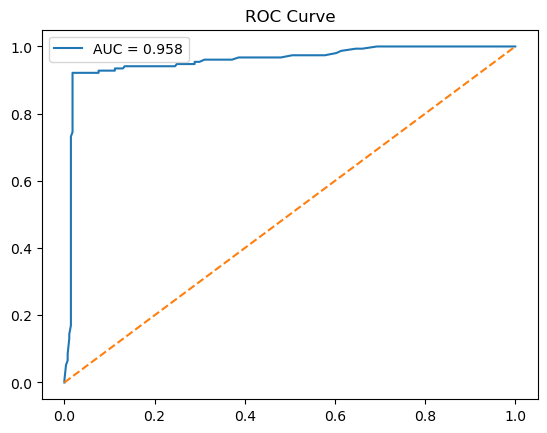

In [42]:
from sklearn.metrics import roc_auc_score,roc_curve
y_prob = RF.predict_proba(x_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

In [43]:
# feature_importance
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": RF.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

feature_importance

,Feature,Importance
0,FunctionalAssessment,0.294311
1,ADL,0.255727
2,MMSE,0.225313
3,MemoryComplaints,0.132779
4,BehavioralProblems,0.091870


# Saving the Model

In [44]:
import pickle

In [45]:
pickle.dump(RF, open("Alzheimers_Random_Forest_Model.pkl","wb"))

In [46]:
import os
os.listdir()

[' Alzheimer’s Disease Classification.ipynb',
 '.ipynb_checkpoints',
 'Alzheimers_Random_Forest_Model.pkl',
 'app.py']

# Deployment

In [47]:
!pip install streamlit

In [48]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# Page Configuration
# -------------------------------------------------

st.set_page_config(
    page_title="Alzheimer's Risk Prediction",
    page_icon="🧠",
    layout="centered"
)

# -------------------------------------------------
# Load Model
# -------------------------------------------------

@st.cache_resource
def load_model():
    with open("Alzheimers_Random_Forest_Model.pkl", "rb") as file:
        model = pickle.load(file)
    return model

model = load_model()

# -------------------------------------------------
# Title
# -------------------------------------------------

st.title("🧠 Alzheimer's Disease Risk Prediction")

st.write(
"""
This AI tool predicts the **risk of Alzheimer's disease**
based on cognitive and behavioral assessments.

⚠️ This tool is for **educational purposes only** and does not replace medical diagnosis.
"""
)

st.divider()

# -------------------------------------------------
# Patient Assessment Section
# -------------------------------------------------

st.header("Patient Assessment")

col1, col2 = st.columns(2)

with col1:

    FunctionalAssessment = st.slider(
        "Functional Assessment Score",
        0.0, 10.0, 5.0
    )

    ADL = st.slider(
        "ADL Score (Activities of Daily Living)",
        0.0, 10.0, 5.0
    )

with col2:

    MMSE = st.slider(
        "MMSE Score",
        0, 30, 15
    )

    MemoryComplaints = st.selectbox(
        "Memory Complaints",
        ["No", "Yes"]
    )

    BehavioralProblems = st.selectbox(
        "Behavioral Problems",
        ["No", "Yes"]
    )

# Encode categorical values

MemoryComplaints = 1 if MemoryComplaints == "Yes" else 0
BehavioralProblems = 1 if BehavioralProblems == "Yes" else 0

st.divider()

# -------------------------------------------------
# Prediction Button
# -------------------------------------------------

if st.button("🔎 Predict Risk Level"):

    # Feature order MUST match training data
    features = np.array([[
        MMSE,
        FunctionalAssessment,
        MemoryComplaints,
        BehavioralProblems,
        ADL
    ]])

    prediction = model.predict(features)[0]

    probability = model.predict_proba(features)[0][1]

    st.subheader("🧠 Prediction Result")

    # Risk Levels

    if probability < 0.30:
        st.success("✅ Low Risk of Alzheimer's Disease")

    elif probability < 0.60:
        st.warning("⚠️ Moderate Risk of Alzheimer's Disease")

    else:
        st.error("🚨 High Risk of Alzheimer's Disease")

    # -------------------------------------------------
    # Probability Display
    # -------------------------------------------------

    st.write("### Risk Probability")

    st.metric(
        label="Risk Score",
        value=f"{probability*100:.2f}%"
    )

    st.progress(int(probability * 100))

    st.divider()

    # -------------------------------------------------
    # Clinical Interpretation
    # -------------------------------------------------

    st.subheader("Clinical Interpretation")

    if probability < 0.30:

        st.info(
            "Patient shows strong cognitive health indicators."
        )

    elif probability < 0.60:

        st.info(
            "Some symptoms suggest possible cognitive decline. "
            "Further clinical evaluation is recommended."
        )

    else:

        st.info(
            "Patient shows strong indicators of Alzheimer's risk. "
            "Immediate medical consultation is advised."
        )

    st.divider()

    # -------------------------------------------------
    # Feature Importance
    # -------------------------------------------------

    st.subheader("Model Feature Importance")

    feature_names = [
        "MMSE",
        "FunctionalAssessment",
        "MemoryComplaints",
        "BehavioralProblems",
        "ADL"
    ]

    importance = model.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)
    
    fig, ax = plt.subplots()
    
    ax.barh(
        importance_df["Feature"],
        importance_df["Importance"],
    )
    
    ax.set_xlabel("Importance Score")
    ax.set_title("Feature Importance in Alzheimer's Prediction")
    
    plt.gca().invert_yaxis()
    
    st.pyplot(fig)

st.divider()

st.caption("Developed using Machine Learning | Random Forest | Streamlit")

Overwriting app.py


In [ ]:
!streamlit run app.py